# Whole-brain neural mass modeling with ``brainmass``

[![Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/chaobrain/brainx/blob/main/docs/tutorials/brainmass_Modeling_MEG_data.ipynb)
[![Open in Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/chaobrain/brainx/blob/main/docs/tutorials/brainmass_Modeling_MEG_data.ipynb)

The previous ``brainmass`` tutorial introduced single-node Jansen-Rit population dynamics. This tutorial moves from a single neural mass node to a whole-brain workflow: a Wilson-Cowan model is simulated across multiple regions, coupled by a structural network, and evaluated against empirical MEG-derived functional connectivity.

You will：
- Build and inspect a single Wilson-Cowan node.
- Extend it to an 80-region network with structural coupling.
- apply the same signal-processing pipeline to simulated and empirical MEG data.
- compare the resulting functional connectivity matrices.

This is a compact workflow introduction, not a full MEG analysis guide. It shows how neural mass dynamics, structural connectivity, stochastic inputs, and empirical validation come together in a eproducible BrainX-style imulation.
For deeper API details and more examples, see the full [brainmass documentation](https://brainx.chaobrain.com/brainmass/). 

## Introduction of Wilson-Cowan Model

The Wilson-Cowan model describes collective neural activity. Instead of modeling individual neurons, it reduces a neural population to two interacting groups: an excitatory population and an inhibitory population. The excitatory population tends to activate connected neural activity, while the inhibitory population suppresses connected neural activity. The core idea is to describe the mean firing rates of these two populations with differential equations, producing rhythmic activity that can resemble real brain dynamics.

The core differential equations are:

$$
\tau_E \dot E = -E + S_E(w_{EE} E - w_{EI} I + I_E + \xi_E)
$$

$$
\tau_I \dot I = -I + S_I(w_{IE} E - w_{II} I + I_I + \xi_I)
$$

| Mathematical symbol | Code variable | Meaning |
| --- | --- | --- |
| $E, I$ | `self.rE.value`, `self.rI.value` | Mean firing rates of the excitatory and inhibitory populations |
| $\tau_E, \tau_I$ | `self.tau_E`, `self.tau_I` | Time constants, usually in milliseconds, that control response speed |
| $w_{EE}, w_{IE}, w_{EI}, w_{II}$ | same names | Connection weights between the populations |
| $r$ | `self.r` | Refractory or self-inhibition strength |
| $I_E(t), I_I(t)$ | `rE_ext`, `rI_ext` | External inputs, optionally including noise |
| $S_j(x)$ | `self.S(x, a, theta)` | Sigmoid response function |

The $S_E(\cdots)$ term applies a sigmoid response function to the total input, including input from other populations and external current. The response function converts input current into firing rate. The $-E$ term is a decay term: without external input, self-excitation, or recurrent drive, the mean firing rate decays toward zero according to its time constant.

## Single-node simulation

How do we model a single node with the Wilson-Cowan model? A single-node simulation represents one local excitatory-inhibitory circuit.

First, import the required tools, including `brainstate`, `braintools`, `brainunit`, `brainmass`, and plotting utilities.

In [43]:
# Import the required tools
import brainstate
import braintools
import brainunit as u
import matplotlib.pyplot as plt
import brainmass

brainstate.environ.set(dt=0.1 * u.ms)

The next example creates a single Wilson-Cowan node and runs it for 10,000 time steps under a constant external input. At each time step, the model returns the excitatory firing rate, and the full trace is collected into the one-dimensional array `exec_activity`.

We instantiate the node with `brainmass.WilsonCowanModel`. Because this is a single-node simulation, the model size is set to `1`. `brainmass.OUProcess` adds Ornstein-Uhlenbeck noise to both the excitatory and inhibitory populations.

The model is then integrated over 10,000 time steps, and the excitatory firing rate from each step is collected in `exec_activity`.

In [44]:
node = brainmass.WilsonCowanModel(
    1,
    noise_E=brainmass.OUProcess(1, sigma=0.01, init=braintools.init.ZeroInit()),
    noise_I=brainmass.OUProcess(1, sigma=0.01, init=braintools.init.ZeroInit()),
)
brainstate.nn.init_all_states(node)

import numpy as np
def step_run(i):
    with brainstate.environ.context(i=i, t=i * brainstate.environ.get_dt()):
        return node.update(0.1)
indices = np.arange(10000)
exec_activity = brainstate.transform.for_loop(step_run, indices)

Plot the simulated activity. The x-axis is physical time and the y-axis is the excitatory firing rate.

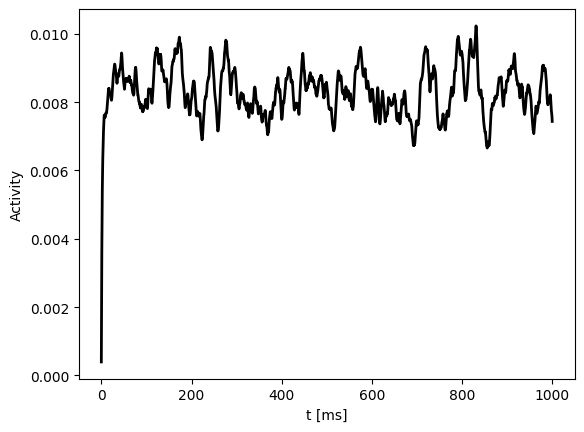

In [45]:
plt.plot(indices * brainstate.environ.get_dt(), exec_activity, c='k', lw=2)
plt.xlabel("t [ms]")
plt.ylabel("Activity")
plt.show()

## Bifurcation diagram

We can use the packaged model to draw a simple one-dimensional bifurcation diagram. The idea is to create 110 independent nodes in parallel, give each node a different constant DC input, run the simulation, and record the steady-state maximum and minimum excitatory firing rates for each input value.

First, generate an arithmetic sequence from 0 to 5.45 with a step size of 0.05. These 110 values are used as independent external inputs. Then create 110 independent nodes at once, run them in parallel under their own constant inputs for 10,000 time steps, and collect the excitatory firing-rate traces.

In [46]:
import numpy as np

exc_inputs = np.arange(0, 5.5, 0.05)

nodes = brainmass.WilsonCowanModel(exc_inputs.size)
brainstate.nn.init_all_states(nodes)

def step_run(i):
    with brainstate.environ.context(i=i, t=i * brainstate.environ.get_dt()):
        return nodes.update(exc_inputs)
indices = np.arange(10000)
exec_activity = brainstate.transform.for_loop(step_run, indices)

For each node, compute the steady-state maximum and minimum of the mean firing rate, then plot the resulting curves.

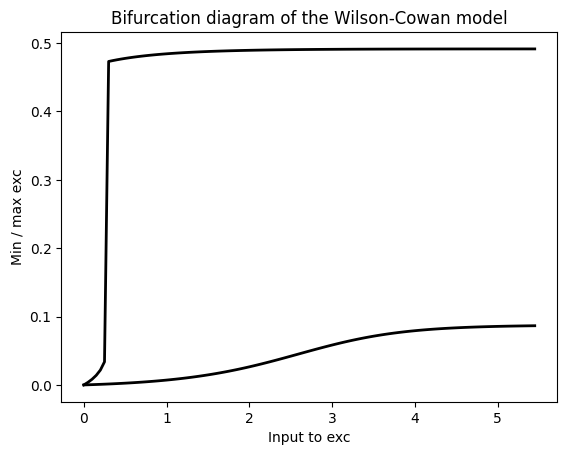

In [47]:
max_exc = exec_activity.max(axis=0)
min_exc = exec_activity.min(axis=0)

plt.plot(exc_inputs, max_exc, c='k', lw=2)
plt.plot(exc_inputs, min_exc, c='k', lw=2)
plt.title("Bifurcation diagram of the Wilson-Cowan model")
plt.xlabel("Input to exc")
plt.ylabel("Min / max exc")
plt.show()

## About Coupling


How do we couple a single node to other nodes? Two common choices are diffusive coupling and additive coupling. The Wilson-Cowan network in this tutorial uses diffusive coupling.

A generic coupling expression is:

$$
current_i(t) = \sum_{j=0}^{N} \mathbf{g}(G_{ij}, \mathbf{x}_i(t), \mathbf{x}_j(t - D_{ij}))
$$

| Symbol | Shape | Source | Meaning |
| --- | --- | --- | --- |
| **G** | N x N | Fiber density or connection probability from DTI tractography | $G_{ij}$ is the anatomical weight from source node $j$ to target node $i$, usually normalized to $[0, 1]$ or kept as the raw FA-derived value. |
| **D** | N x N | Fiber length divided by signal velocity, about 5-10 m/s | $D_{ij}$ is the axonal transmission delay from node $j$ to node $i$, measured in milliseconds. |

Diffusive coupling can be written as:

$$
\text{current}_i = k \cdot \sum_j g_{ij} \cdot (x_j - y_i)
$$

- $\text{current}_i$: the net input current received by target brain region $i$.
- $k$: global coupling strength, which scales the overall influence of the network.
- $g_{ij}$: the connection weight from source region $j$ to target region $i$.
- $(\mathbf{x}_i(t), \mathbf{x}_j(t - D_{ij}))$: this term represents the activity difference between the delayed source region and the target region. If the source region is more active than the target, the term is positive and increases the target activity; if it is negative, it suppresses or reduces the target activity.

This coupling tends to reduce activity differences between connected regions and can promote synchronization or collective oscillation.

Additive coupling can be written as:

$$
\text{current}_i = k \cdot \sum_j g_{ij} \cdot x_j
$$

In additive coupling, the input received by region $i$ is determined only by the activity of neighboring regions and their connection strengths, scaled by the global coupling strength $k$. This is often used to model feedforward information flow.

## Brain Network

Next, we build a whole-brain model. A general whole-brain equation is:

$$
\frac{d}{dt}\mathbf{x}_i(t) = \mathbf{f}(\mathbf{x}_i(t)) + \sum_{j=0}^{N} \mathbf{g}(G_{ij}, \mathbf{x}_i(t), \mathbf{x}_j(t - D_{ij})) + \boldsymbol{\mu}_i(t)
$$

In words, each node's state change is the sum of local dynamics, global coupling, and noise.

| Symbol | Size | Meaning |
| --- | --- | --- |
| **N** | scalar | Total number of brain regions or nodes, such as 68 for the Desikan-Killiany atlas or 90 for AAL. |
| **i/j in [0, N-1]** | index | The $i$-th or $j$-th brain region. |

The main modeling differences come from the choice of local dynamical model. This tutorial uses the Wilson-Cowan model; other common options include Hopf, ALN, and Wong-Wang models. The coupling function transfers information across nodes by using the state of distant nodes as input to the current node. Coupling can be additive, diffusive, nonlinear, or another model-specific form.

We need structural connectivity data. Here we use HCP DTI structural data stored in the dataset, usually including `Cmat` and `Dmat`. `Cmat` stores connection strengths between brain regions, while `Dmat` stores fiber lengths between regions.

The `Network` class builds a whole-brain model with 80 Wilson-Cowan nodes. It first computes the connection strengths and delay times. Delay is obtained by dividing the fiber length in `Dmat` by the signal conduction speed. The code then builds an index matrix and delay views along structural edges. Coupling is diffusive: the input is computed from target-node activity and delayed neighboring activity, scaled by the global coupling coefficient `k`. The resulting input is integrated into the updated excitatory rate `rE`.

In [48]:
import os.path
import kagglehub
path = kagglehub.dataset_download("oujago/hcp-gw-data-samples")
hcp = braintools.file.msgpack_load(os.path.join(path, "hcp-data-sample.msgpack"))

In [49]:
class Network(brainstate.nn.Module):
    def __init__(self, signal_speed=2., k=1.):
        super().__init__()

        conn_weight = hcp['Cmat'].copy()
        np.fill_diagonal(conn_weight, 0)
        delay_time = hcp['Dmat'] / signal_speed
        np.fill_diagonal(delay_time, 0)
        indices_ = np.arange(conn_weight.shape[1])
        indices_ = np.tile(np.expand_dims(indices_, axis=0), (conn_weight.shape[0], 1))

        self.node = brainmass.WilsonCowanModel(
            80,
            noise_E=brainmass.OUProcess(80, sigma=0.01, init=braintools.init.ZeroInit()),
            noise_I=brainmass.OUProcess(80, sigma=0.01, init=braintools.init.ZeroInit()),
        )
        self.coupling = brainmass.DiffusiveCoupling(
            self.node.prefetch_delay('rE', (delay_time * u.ms, indices_), init=braintools.init.Uniform(0, 0.05)),
            self.node.prefetch('rE'),
            conn_weight,
            k=k
        )

    def update(self):
        current = self.coupling()
        rE = self.node(current)
        return rE

    def step_run(self, i):
        with brainstate.environ.context(i=i, t=i * brainstate.environ.get_dt()):
            return self.update()

Cmat shape: (80, 80)
Dmat shape: (80, 80)


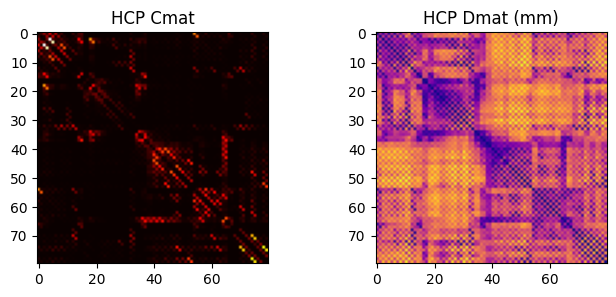

In [50]:
print('Cmat shape:', hcp['Cmat'].shape)   # (80, 80)
print('Dmat shape:', hcp['Dmat'].shape)   # (80, 80)
fig, ax = plt.subplots(1,2, figsize=(8,3))
ax[0].imshow(hcp['Cmat'], cmap='hot'); ax[0].set_title('HCP Cmat')
ax[1].imshow(hcp['Dmat'], cmap='plasma'); ax[1].set_title('HCP Dmat (mm)')
plt.show()

In [51]:
net = Network()
brainstate.nn.init_all_states(net)
indices = np.arange(0, 6e3 // (brainstate.environ.get_dt() / u.ms))
exes = brainstate.transform.for_loop(net.step_run, indices)

Finally, compute the functional connectivity matrix and plot it. This gives a simple view of the relationship between structural connectivity and simulated functional connectivity.

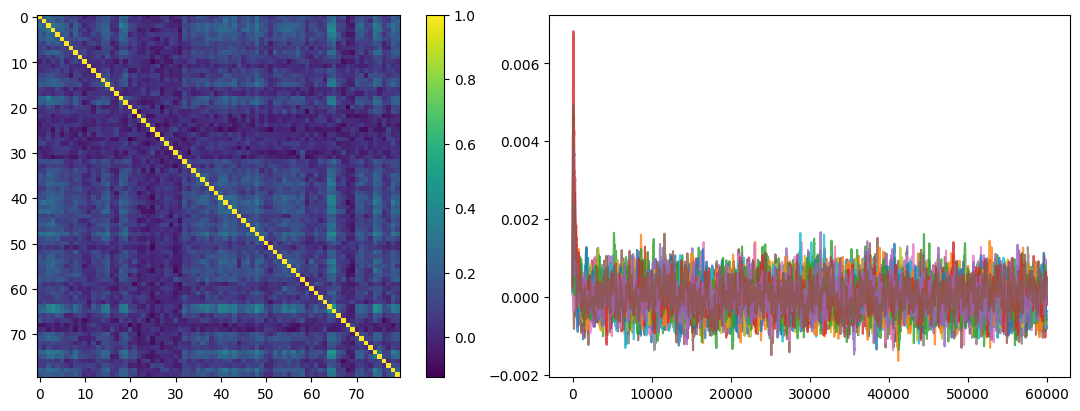

In [52]:
fig, gs = braintools.visualize.get_figure(1, 2, 4, 6)
ax1 = fig.add_subplot(gs[0, 0])
fc = braintools.metric.functional_connectivity(exes)
ax = ax1.imshow(fc)
plt.colorbar(ax, ax=ax1)
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(indices, exes[:, ::5], alpha=0.8)
plt.show()

## Fit MEG functional connectivity

The previous sections covered basic simulation and analysis. We now use the whole-brain simulation to fit MEG functional connectivity.

First, compute the original sampling rate and the number of brain regions, then wrap the simulated signal in an `xarray.DataArray` for easier downstream processing.

In [53]:
# Import the required tools
import xarray as xr

dt_ms = brainstate.environ.get_dt()
original_fs = 1000. / dt_ms 
num_regions = exes.shape[1]
time_points_orig = indices * dt_ms / 1000. 
time_points_orig = np.asarray(time_points_orig.magnitude)

region_labels = [f'Region_{i}' for i in range(num_regions)]
sim_signal_raw = xr.DataArray(
    exes, 
    dims=("time", "regions"), 
    coords={"time": time_points_orig, "regions": region_labels}
)

Next, process the raw simulated data according to the signal band of interest. The pipeline includes resampling, band-pass filtering, amplitude-envelope extraction, and low-pass filtering. This makes the simulated signal comparable to the empirical MEG processing pipeline.

First, downsample the high-rate simulation signal from 10 kHz to 100 Hz so that subsequent analysis can focus on the 0-50 Hz range, matching the empirical MEG data.

In [54]:
from scipy.signal import resample, butter, filtfilt, hilbert

In [55]:
target_fs = 100.0
ratio = len(time_points_orig) * target_fs / original_fs
num_samples_new = int(ratio.magnitude)
# resample
resampled_data, resampled_time = resample(sim_signal_raw, num_samples_new, t=time_points_orig)

sim_signal = xr.DataArray(
    resampled_data,
    dims=("time", "regions"),
    coords={"time": resampled_time, "regions": region_labels}
)
print(f"Original sampling rate: {original_fs} Hz. Resampled to: {target_fs} Hz.")

Original sampling rate: 10000. kHz Hz. Resampled to: 100.0 Hz.


Next, define a band-pass filter and a low-pass filter for frequency-specific analysis.

In [56]:
#  bandpass filter
def butter_bandpass_filter(data, lowcut, highcut, fs, order=3):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    y = filtfilt(b, a, data)
    return y

# low-pass filter
def butter_lowpass_filter(data, highcut, fs, order=3):
    nyq = 0.5 * fs
    high = highcut / nyq
    b, a = butter(order, high, btype='low')
    y = filtfilt(b, a, data)
    return y

After choosing a region of interest, filter the signal to the 8-12 Hz alpha band, apply the Hilbert transform to obtain the analytic signal, extract the instantaneous amplitude envelope, and finally low-pass filter the envelope to reveal slow dynamics.

In [57]:
target_region = 'Region_0'  # Select the first brain region for analysis
signal_to_process = sim_signal.sel(regions=target_region).values

# bandpass filter
freq_band = [8.0, 12.0]  # alpha band
filtered_signal = butter_bandpass_filter(signal_to_process, freq_band[0], freq_band[1], fs=target_fs)

# hilbert
analytic_signal = hilbert(filtered_signal)
signal_envelope = np.abs(analytic_signal)

# low-pass
low_pass_cutoff = 4.0
smoothed_envelope = butter_lowpass_filter(signal_envelope, low_pass_cutoff, fs=target_fs)

Plot the band-pass filtered signal, the amplitude envelope, and the low-pass filtered envelope. These are the simulated signals used in the MEG-fitting workflow.

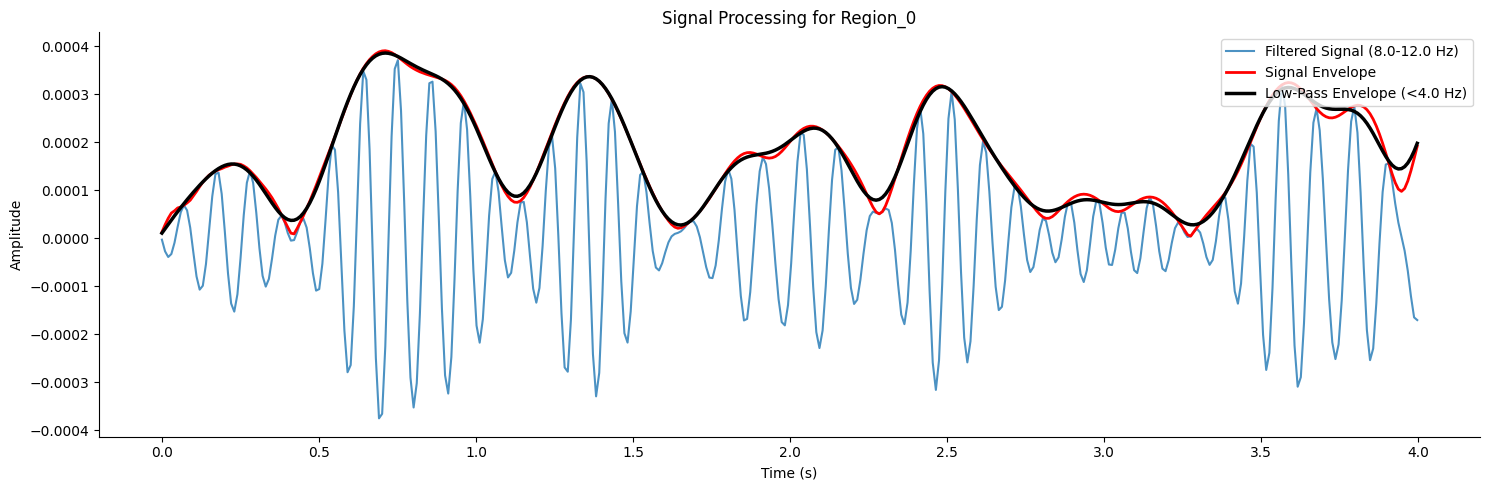

In [58]:
fig_signal, ax_signal = plt.subplots(figsize=(15, 5))
plot_duration_s = 4  # Plot 4 seconds
plot_timepoints = int(plot_duration_s * target_fs)
time_axis = sim_signal.time.values[:plot_timepoints]
ax_signal.plot(time_axis, filtered_signal[:plot_timepoints], label=f'Filtered Signal ({freq_band[0]}-{freq_band[1]} Hz)', alpha=0.8)
ax_signal.plot(time_axis, signal_envelope[:plot_timepoints], label='Signal Envelope', linewidth=2, color='red')
ax_signal.plot(time_axis, smoothed_envelope[:plot_timepoints], label=f'Low-Pass Envelope (<{low_pass_cutoff} Hz)', linewidth=2.5, color='black')
ax_signal.set_title(f'Signal Processing for {target_region}')
ax_signal.set_xlabel('Time (s)')
ax_signal.set_ylabel('Amplitude')
ax_signal.legend(loc='upper right')
ax_signal.spines['top'].set_visible(False)
ax_signal.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## Process empirical data

Next, process the empirical MEG data. We load resting-state MEG data from the HCP dataset, read the region labels, and compute the original sampling rate.

In [59]:
path = kagglehub.dataset_download("oujago/meg-data-samples")
meg_data = xr.open_dataset(os.path.join(path, 'rs-meg.nc'))

region_labels = meg_data.regions.values
sampling_rate = 1 / (meg_data.time[1] - meg_data.time[0]).item() # Calculate sampling rate from time coordinates
display(f"Data loaded with {len(region_labels)} regions. Sampling rate: {sampling_rate:.2f} Hz")

'Data loaded with 94 regions. Sampling rate: 100.00 Hz'

Set up interactive widgets to choose a brain region and frequency band of interest.

In [60]:
import ipywidgets as widgets

print('Select a region from the AAL2 atlas and a frequency range')
# Select a Region 
target = widgets.Select(options=region_labels, value='PreCG.L', description='Regions', 
                        tooltips=['Description of slow', 'Description of regular', 'Description of fast'], 
                        layout=widgets.Layout(width='50%', height='150px'))
display(target)

# Select Frequency Range
freq = widgets.IntRangeSlider(min=1, max=46, description='Frequency (Hz)', value=[8, 12], layout=widgets.Layout(width='80%'), 
                              style={'description_width': 'initial'})
display(freq)

plot_timepoints = 1000

meg_array = meg_data['__xarray_dataarray_variable__']
if meg_array.dims[0] != 'time':
    meg_array = meg_array.transpose('time', 'regions')    
fs = sampling_rate                                   
low, high = freq.value                              
plot_len = int(plot_timepoints)                     
time_vals = meg_array.time[:plot_len].values 

Select a region from the AAL2 atlas and a frequency range


Select(description='Regions', layout=Layout(height='150px', width='50%'), options=('PreCG.L', 'PreCG.R', 'SFG.…

IntRangeSlider(value=(8, 12), description='Frequency (Hz)', layout=Layout(width='80%'), max=46, min=1, style=S…

Using the selected region and frequency band, apply band-pass filtering and plot the result. The top panel shows the raw signal from the selected region, and the bottom panel shows the filtered signal and its amplitude envelope.

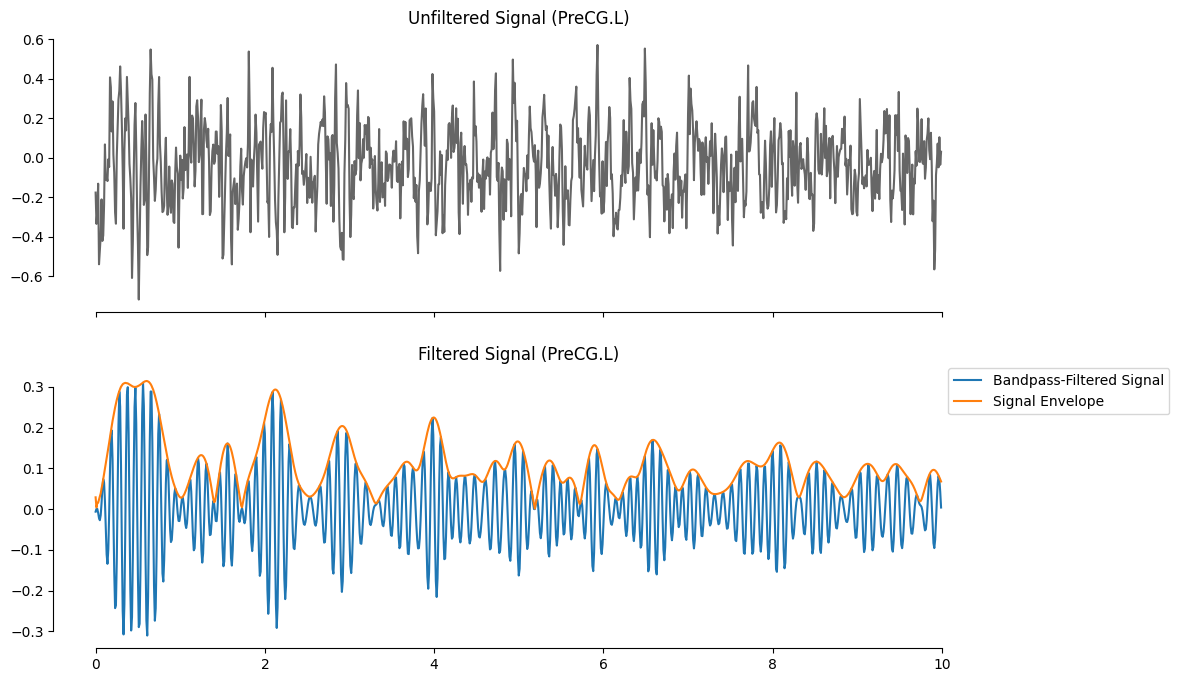

In [61]:
import seaborn as sns

fig, ax = plt.subplots(2, 1, figsize=(12,8), sharex=True)
y_raw_target = meg_array.sel(regions=target.value).values 
sns.lineplot(x=time_vals, y=y_raw_target[:plot_len], ax=ax[0], color='k', alpha=0.6)
ax[0].set_title(f'Unfiltered Signal ({target.value})')

# Band Pass Filter the Signal
y_filt_target = butter_bandpass_filter(y_raw_target, low, high, fs)
y_env_target  = np.abs(hilbert(y_filt_target))  

sns.lineplot(x=time_vals, y=y_filt_target[:plot_len], ax=ax[1], label='Bandpass-Filtered Signal')
sns.lineplot(x=time_vals, y=y_env_target[:plot_len], ax=ax[1], label='Signal Envelope')
ax[1].set_title(f'Filtered Signal ({target.value})');
ax[1].legend(bbox_to_anchor=(1.2, 1),borderaxespad=0)
sns.despine(trim=True)
plt.show()

Next, orthogonalize the signal. MEG records mixtures of multiple neural sources, and field spread can introduce spurious functional connectivity: two sensors or regions may capture the same underlying source. To reduce this effect, orthogonalization removes from each target-region signal the component that has the same phase as the reference-region signal, leaving the target-region activity that is independent of the reference. This improves the spatial specificity and reliability of MEG functional connectivity.

The formula is:

$$
Y_{ix}(t, f) = \text{imag}\left(\frac{Y(t, f)}{X(t, f)^*}\right)
$$

Here, $Y$ is the analytic signal from the target region. Orthogonalizing it with respect to the reference signal $X$ removes the component phase-aligned with $X$ and retains the part of $Y$ that is independent of $X$.

In [62]:
# Orthogonalized signal envelope
print('Select a reference region for the orthogonalization')
# Select a Region 
referenz = widgets.Select(options=region_labels, value='PreCG.R', description='Regions',
                          tooltips=['Description of slow', 'Description of regular', 'Description of fast'],
                          layout=widgets.Layout(width='50%', height='150px'))
display(referenz)

y_raw_reference = meg_array.sel(regions=referenz.value).values
y_filt_reference = butter_bandpass_filter(y_raw_reference, low, high, fs)

complex_target = hilbert(y_filt_target)
complex_reference = hilbert(y_filt_reference)
env_reference = np.abs(complex_reference)
env_target = np.abs(complex_target)

signal_conj_div_env = complex_reference.conj() / env_reference
orth_signal_imag = (complex_target * signal_conj_div_env).imag
orth_env = np.abs(orth_signal_imag)

Select a reference region for the orthogonalization


Select(description='Regions', index=1, layout=Layout(height='150px', width='50%'), options=('PreCG.L', 'PreCG.…

The plot below shows the reference-region signal and amplitude envelope in the top panel, and the target-region signal, amplitude envelope, and orthogonalized envelope in the bottom panel. Note that this operation is applied only to empirical data; the simulated signal does not need this correction.

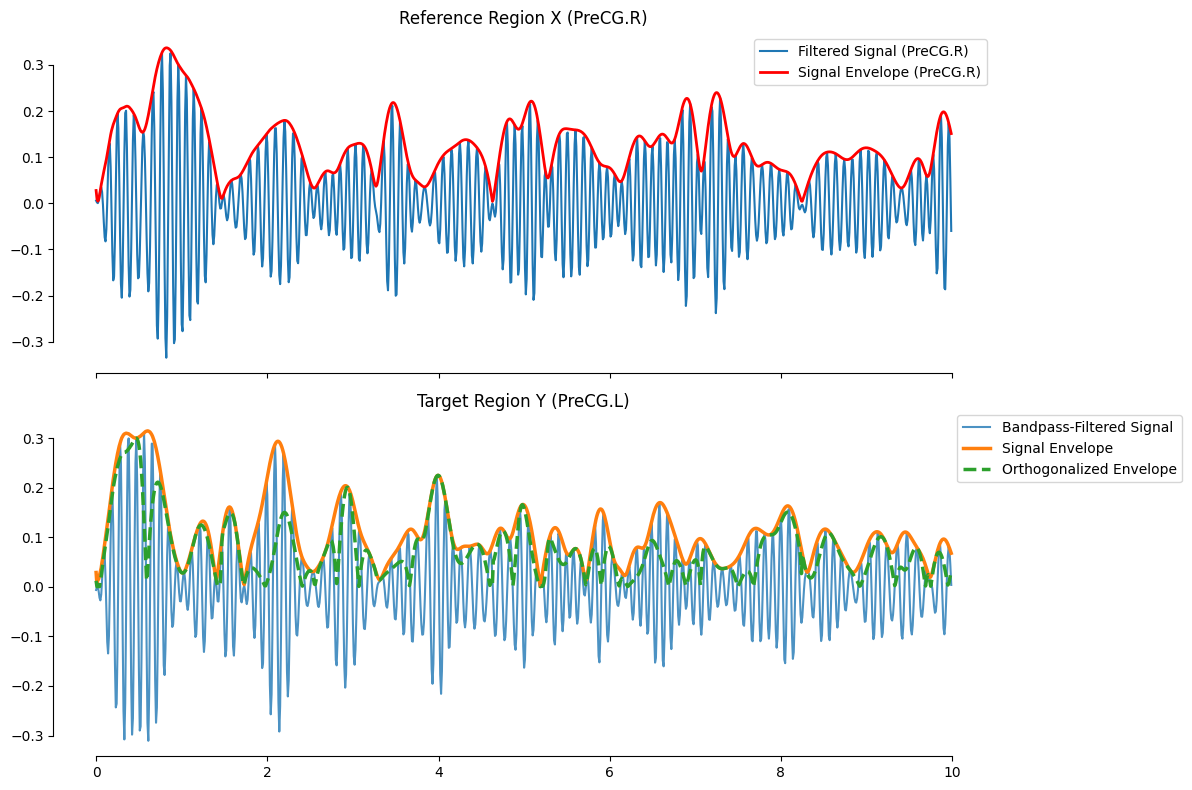

In [63]:
fig_final, ax_final = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
ax_final[0].plot(time_vals, y_filt_reference[:plot_len], label=f'Filtered Signal ({referenz.value})')
ax_final[0].plot(time_vals, env_reference[:plot_len], label=f'Signal Envelope ({referenz.value})', color='red', linewidth=2)
ax_final[0].set_title(f'Reference Region X ({referenz.value})')
ax_final[0].legend()

ax_final[1].plot(time_vals, y_filt_target[:plot_len], label='Bandpass-Filtered Signal', alpha=0.8)
ax_final[1].plot(time_vals, env_target[:plot_len], label='Signal Envelope', linewidth=2.5)
ax_final[1].plot(time_vals, orth_env[:plot_len], label='Orthogonalized Envelope', linewidth=2.5, linestyle='--')
ax_final[1].set_title(f'Target Region Y ({target.value})')
ax_final[1].legend(bbox_to_anchor=(1.2, 1), borderaxespad=0)

sns.despine(trim=True)
plt.tight_layout()
plt.show()

Pass both the reference-region amplitude envelope and the orthogonalized target-region envelope through a low-pass filter to isolate their low-frequency components. These low-frequency envelopes are the final signals used for functional connectivity.

FloatSlider(value=1.0, description='Low-Pass Frequency (Hz)', layout=Layout(width='80%'), max=2.0, readout_for…

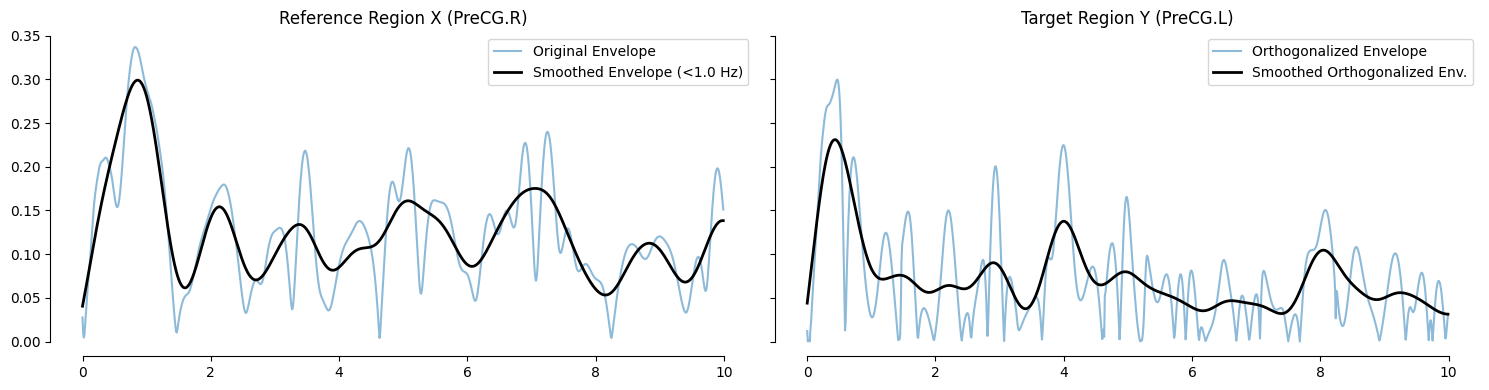


Orthogonalized envelope correlation between PreCG.R and PreCG.L: 0.20


In [64]:
low_pass = widgets.FloatSlider(value=1.0, min=0, max=2.0, step=0.1, description='Low-Pass Frequency (Hz)', 
                               disabled=False, readout=True, readout_format='.1f', layout=widgets.Layout(width='80%'), 
                               style={'description_width': 'initial'})
display(low_pass)

low_orth_env = butter_lowpass_filter(orth_env, highcut=low_pass.value, fs=fs)
low_signal_env = butter_lowpass_filter(env_reference, highcut=low_pass.value, fs=fs)

# Plot the smoothed envelopes for comparison
fig_corr, ax_corr = plt.subplots(1, 2, figsize=(15, 4), sharey=True)

# Plot for the reference region
ax_corr[0].plot(time_vals, env_reference[:plot_len], alpha=0.5, label='Original Envelope')
ax_corr[0].plot(time_vals, low_signal_env[:plot_len], color='black', lw=2, label=f'Smoothed Envelope (<{low_pass.value} Hz)')
ax_corr[0].set_title(f'Reference Region X ({referenz.value})')
ax_corr[0].legend()

# Plot for the target region
ax_corr[1].plot(time_vals, orth_env[:plot_len], alpha=0.5, label='Orthogonalized Envelope')
ax_corr[1].plot(time_vals, low_orth_env[:plot_len], color='black', lw=2, label='Smoothed Orthogonalized Env.')
ax_corr[1].set_title(f'Target Region Y ({target.value})')
ax_corr[1].legend()

sns.despine(trim=True)
plt.tight_layout()
plt.show()

correlation = np.corrcoef(low_orth_env, low_signal_env)[0, 1]
print(f'\nOrthogonalized envelope correlation between {referenz.value} and {target.value}: {correlation:.2f}')

## Compute the functional connectivity matrix

Next, compute functional connectivity matrices for the processed simulated and empirical signals. The function below loops over every pair of brain regions and applies the full processing pipeline: band-pass filtering, envelope extraction, orthogonalization when required, low-pass filtering, and pairwise envelope correlation.

In [65]:
def calculate_orthogonalized_fc(meg_data, band, fs, low_pass_cutoff):
    num_regions = meg_data.shape[1]
    
    # Z-score standardize the raw signals from all brain regions to ensure robustness of the results.
    meg_array_mean = meg_data.mean(dim='time')
    meg_array_std = meg_data.std(dim='time')
    meg_data_normalized = (meg_data - meg_array_mean) / meg_array_std
    
    # Apply band-pass and low-pass filtering
    y_filt_all = butter_bandpass_filter(meg_data_normalized.values, band[0], band[1], fs)
    complex_all = hilbert(y_filt_all, axis=0)
    env_all = np.abs(complex_all) 
    conj_div_env_all = complex_all.conj() / env_all
    low_pass_env_all = butter_lowpass_filter(env_all, highcut=low_pass_cutoff, fs=fs)

    # Iteratively compute orthogonalization and correlation
    fc_matrix = np.zeros((num_regions, num_regions))
    
    progress = widgets.IntProgress(min=0, max=num_regions, description='Computing FC:',
                                   layout=widgets.Layout(width='80%'), style={'description_width': 'initial'})
    display(progress)
    
    for i in range(num_regions):
        complex_target = complex_all[:, i]
        orth_signal_imag = (complex_target[:, np.newaxis] * conj_div_env_all).imag
        orth_env = np.abs(orth_signal_imag)
        low_pass_orth_env = butter_lowpass_filter(orth_env, highcut=low_pass_cutoff, fs=fs)
        corr_mat = np.corrcoef(low_pass_orth_env.T, low_pass_env_all.T)
        corr_row = np.diag(corr_mat, k=num_regions)
        fc_matrix[i, :] = corr_row
        progress.value += 1
        
    fc_matrix = (fc_matrix + fc_matrix.T) / 2
    np.fill_diagonal(fc_matrix, 0)
    
    display("FC Matrix calculation complete.")
    return fc_matrix

Define a helper function to visualize a functional connectivity matrix as a standard red-blue symmetric heatmap.

In [66]:
def plot_fc_heatmap(fc_matrix, labels, title, ax):
    vmax = np.max(np.abs(fc_matrix))
    
    sns.heatmap(
        fc_matrix,
        square=True,
        ax=ax,
        cmap='RdBu_r',
        vmin=-vmax,
        vmax=vmax,
        cbar_kws={"shrink": .8}
    )
    
    num_regions = len(labels)
    tick_spacing = max(1, num_regions // 20)
    
    cleaned_labels = [str(label).replace('.L', '').replace('.R', '') for label in labels]
    
    ax.set_xticks(np.arange(0, num_regions, tick_spacing))
    ax.set_yticks(np.arange(0, num_regions, tick_spacing))
    ax.set_xticklabels(cleaned_labels[::tick_spacing], rotation=90, fontsize=8)
    ax.set_yticklabels(cleaned_labels[::tick_spacing], rotation=0, fontsize=8)
    ax.set_title(title)

Compute and plot the functional connectivity matrix from the empirical MEG signal.

IntProgress(value=0, description='Computing FC:', layout=Layout(width='80%'), max=94, style=ProgressStyle(desc…

'FC Matrix calculation complete.'


Plotting FC Matrix for real MEG data (Default Order)...


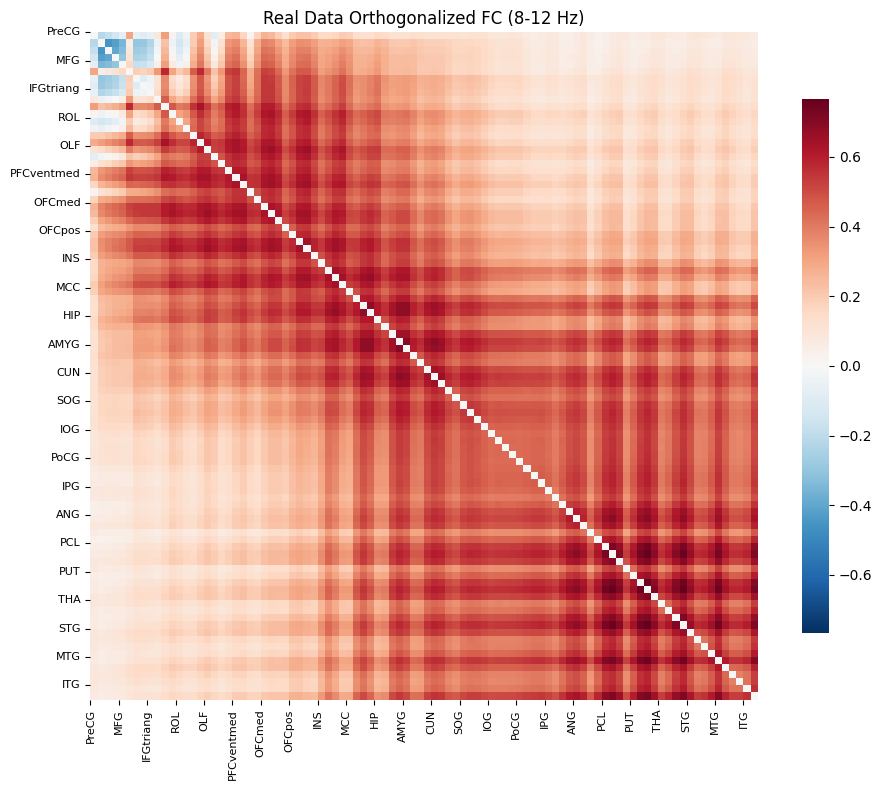

In [67]:
# Execute the function with the parameters from the widgets
fc_matrix = calculate_orthogonalized_fc(
    meg_data=meg_array, 
    band=freq.value, 
    fs=fs, 
    low_pass_cutoff=low_pass.value
)

print("\nPlotting FC Matrix for real MEG data (Default Order)...")

fig_real, ax_real = plt.subplots(figsize=(10, 8))
plot_fc_heatmap(
    fc_matrix=fc_matrix,
    labels=region_labels, 
    title=f'Real Data Orthogonalized FC ({freq.value[0]}-{freq.value[1]} Hz)',
    ax=ax_real
)
plt.tight_layout()
plt.show()

Compute and plot the functional connectivity matrix from the simulated signal.


Please select parameters for the simulation FC calculation:


IntRangeSlider(value=(8, 12), description='Frequency (Hz)', layout=Layout(width='80%'), max=45, min=1, style=S…

FloatSlider(value=2.0, description='Low-Pass (Hz)', layout=Layout(width='80%'), max=4.0, readout_format='.1f',…

IntProgress(value=0, description='Computing FC:', layout=Layout(width='80%'), max=80, style=ProgressStyle(desc…

'FC Matrix calculation complete.'

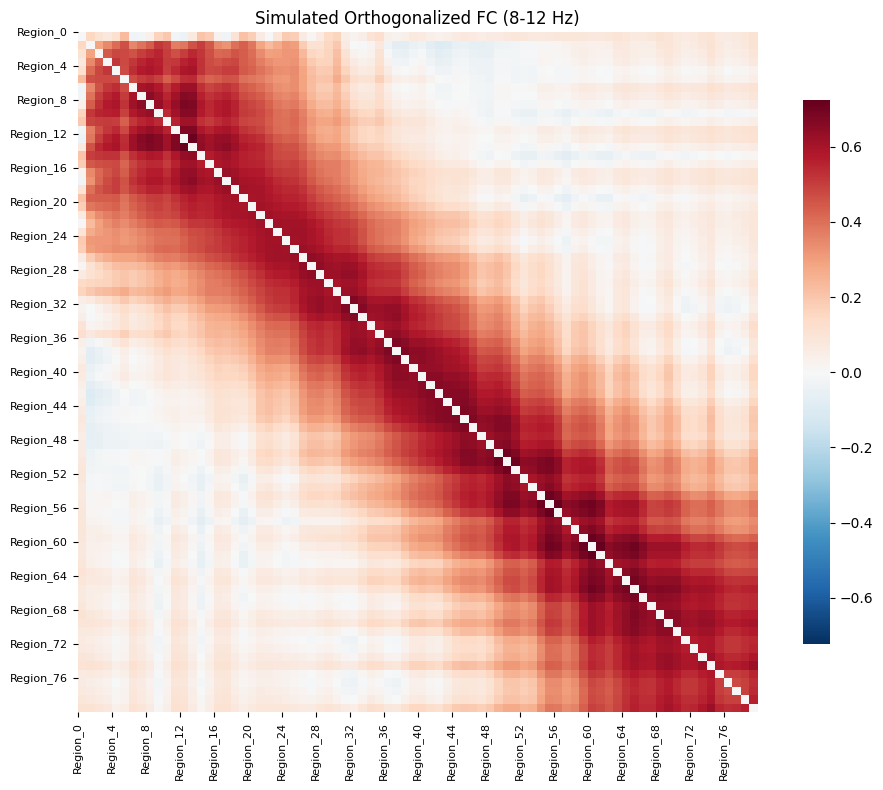

In [68]:
print("\nPlease select parameters for the simulation FC calculation:")
sim_freq_band = widgets.IntRangeSlider(
    value=[8, 12], min=1, max=45, description='Frequency (Hz)',
    layout=widgets.Layout(width='80%'), style={'description_width': 'initial'}
)
sim_low_pass = widgets.FloatSlider(
    value=2.0, min=0, max=4.0, step=0.1, description='Low-Pass (Hz)',
    readout=True, readout_format='.1f',
    layout=widgets.Layout(width='80%'), style={'description_width': 'initial'}
)
display(sim_freq_band)
display(sim_low_pass)

fc_matrix_sim = calculate_orthogonalized_fc(
    meg_data=sim_signal,
    band=sim_freq_band.value,
    fs=target_fs,
    low_pass_cutoff=sim_low_pass.value
)

sim_labels = sim_signal.regions.values
fig_sim, ax_sim = plt.subplots(figsize=(10, 8))
plot_fc_heatmap(
    fc_matrix=fc_matrix_sim,
    labels=sim_labels, 
    title=f'Simulated Orthogonalized FC ({sim_freq_band.value[0]}-{sim_freq_band.value[1]} Hz)',
    ax=ax_sim
)
plt.tight_layout()
plt.show()

## Compute similarity

Finally, flatten the simulated and empirical functional connectivity matrices into vectors, compute their Pearson correlation, and display the model fit as a bar plot. This provides a direct visual summary of how well the simulated network reproduces empirical MEG functional connectivity.


Comparing the 80x80 simulated FC with the corresponding subset of the real MEG FC.


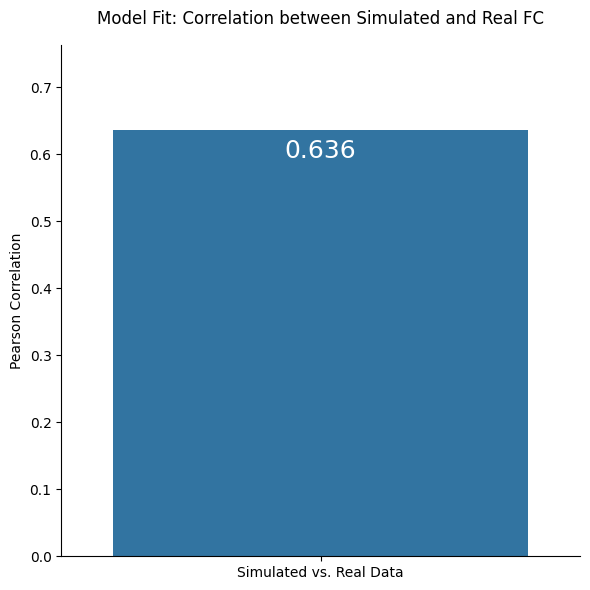

The correlation between the simulated FC and the real MEG data FC is: 0.636


In [69]:
num_sim_regions = fc_matrix_sim.shape[0]
fc_matrix_real_matched = fc_matrix[:num_sim_regions, :num_sim_regions]
print(f"\nComparing the {num_sim_regions}x{num_sim_regions} simulated FC with the corresponding subset of the real MEG FC.")
indices_triu = np.triu_indices(num_sim_regions, k=1)
real_fc_flat = fc_matrix_real_matched[indices_triu]
sim_fc_flat = fc_matrix_sim[indices_triu]

# Calculate the Pearson correlation between the two flattened FC vectors
sim_vs_real_corr = np.corrcoef(real_fc_flat, sim_fc_flat)[0, 1]
fig_comp, ax_comp = plt.subplots(figsize=(6, 6))

splot = sns.barplot(
    x=['Simulated vs. Real Data'],
    y=[sim_vs_real_corr],
    ax=ax_comp
)

ax_comp.set_ylabel('Pearson Correlation')
ax_comp.set_title('Model Fit: Correlation between Simulated and Real FC', pad=15)
ax_comp.set_ylim(0, max(0.5, sim_vs_real_corr * 1.2)) 

# Add the correlation value as text on the bar
for p in splot.patches:
    splot.annotate(
        format(p.get_height(), '.3f'), 
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', va='center', 
        size=18, color='white',
        xytext=(0, -15), 
        textcoords='offset points'
    )

sns.despine()
plt.tight_layout()
plt.show()
print(f"The correlation between the simulated FC and the real MEG data FC is: {sim_vs_real_corr:.3f}")